In [93]:
import pandas as pd
import numpy as np

In [94]:
df=pd.read_csv('Admission_Predict.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [96]:
df.duplicated().sum()

0

In [97]:
df=df.drop(columns=['Serial No.'])

In [98]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [99]:
x

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [100]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
395    0.82
396    0.84
397    0.91
398    0.67
399    0.95
Name: Chance of Admit , Length: 400, dtype: float64

In [101]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [102]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [103]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [104]:
x_test_scaled

array([[ 0.36170213,  0.53571429,  0.5       ,  0.625     ,  0.57142857,
         0.60128617,  0.        ],
       [ 0.65957447,  0.67857143,  1.        ,  0.875     ,  0.71428571,
         0.75884244,  1.        ],
       [ 0.27659574,  0.46428571,  0.25      ,  0.5       ,  0.28571429,
         0.46945338,  0.        ],
       [ 0.78723404,  0.75      ,  1.        ,  1.        ,  0.71428571,
         0.80707395,  1.        ],
       [ 0.80851064,  0.82142857,  1.        ,  0.875     ,  0.57142857,
         0.82315113,  1.        ],
       [ 0.65957447,  0.75      ,  0.75      ,  0.875     ,  0.71428571,
         0.63987138,  0.        ],
       [ 0.57446809,  0.42857143,  0.5       ,  0.5       ,  0.57142857,
         0.62379421,  1.        ],
       [ 0.4893617 ,  0.25      ,  0.25      ,  0.375     ,  0.42857143,
         0.7073955 ,  0.        ],
       [ 0.40425532,  0.32142857,  0.25      ,  0.375     ,  0.57142857,
         0.39871383,  1.        ],
       [ 0.89361702,  0.8928

In [105]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [106]:
model=Sequential()

In [107]:
model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(1,activation='linear'))

In [108]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_17 (Dense)            (None, 7)                 56        
                                                                 
 dense_18 (Dense)            (None, 1)                 8         
                                                                 
Total params: 64 (256.00 Byte)
Trainable params: 64 (256.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [109]:
model.compile(loss='mean_squared_error',optimizer="adam")

In [110]:
history=model.fit(x_train_scaled,y_train,epochs=10)

Epoch 1/10
10/10 [==============================] - 0s 2ms/step - loss: 0.6146
Epoch 2/10
10/10 [==============================] - 0s 1ms/step - loss: 0.5224
Epoch 3/10
10/10 [==============================] - 0s 1ms/step - loss: 0.4488
Epoch 4/10
10/10 [==============================] - 0s 1ms/step - loss: 0.3855
Epoch 5/10
10/10 [==============================] - 0s 1ms/step - loss: 0.3340
Epoch 6/10
10/10 [==============================] - 0s 1ms/step - loss: 0.2907
Epoch 7/10
10/10 [==============================] - 0s 1ms/step - loss: 0.2519
Epoch 8/10
10/10 [==============================] - 0s 2ms/step - loss: 0.2168
Epoch 9/10
10/10 [==============================] - 0s 1ms/step - loss: 0.1868
Epoch 10/10
10/10 [==============================] - 0s 1ms/step - loss: 0.1603


In [111]:
y_pred=model.predict(x_test_scaled)

3/3 [==============================] - 0s 3ms/step


In [112]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

-8.56706329921739

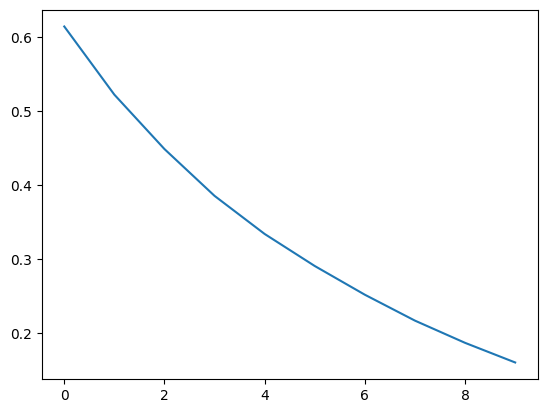

In [113]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

## improving the model using different technique

In [114]:
model2=Sequential()

In [115]:
model2.add(Dense(7,activation='relu',input_dim=7))
model2.add(Dense(7,activation='relu',input_dim=7))
model2.add(Dense(1,activation='linear'))

In [116]:
model2.compile(loss='mean_squared_error',optimizer="adam")


In [117]:
history1=model2.fit(x_train_scaled,y_train,epochs=100)


Epoch 1/100
10/10 [==============================] - 1s 1ms/step - loss: 0.0782
Epoch 2/100
10/10 [==============================] - 0s 2ms/step - loss: 0.0643
Epoch 3/100
10/10 [==============================] - 0s 1ms/step - loss: 0.0525
Epoch 4/100
10/10 [==============================] - 0s 1ms/step - loss: 0.0420
Epoch 5/100
10/10 [==============================] - 0s 1ms/step - loss: 0.0353
Epoch 6/100
10/10 [==============================] - 0s 1ms/step - loss: 0.0289
Epoch 7/100
10/10 [==============================] - 0s 1ms/step - loss: 0.0239
Epoch 8/100
10/10 [==============================] - 0s 2ms/step - loss: 0.0196
Epoch 9/100
10/10 [==============================] - 0s 2ms/step - loss: 0.0162
Epoch 10/100
10/10 [==============================] - 0s 1ms/step - loss: 0.0140
Epoch 11/100
10/10 [==============================] - 0s 2ms/step - loss: 0.0121
Epoch 12/100
10/10 [==============================] - 0s 2ms/step - loss: 0.0108
Epoch 13/100
10/10 [=================

In [118]:
y_pred=model2.predict(x_test_scaled)
r2_score(y_test,y_pred)


3/3 [==============================] - 0s 2ms/step


0.7903429344476892

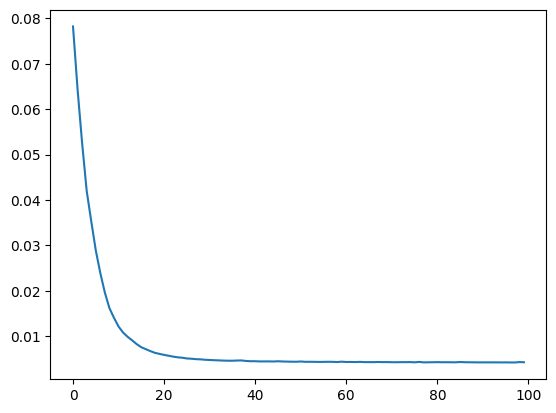

In [119]:
import matplotlib.pyplot as plt
plt.plot(history1.history['loss'])